Dataset Shape: (10000, 14)

Columns: Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000


ROC-AUC Score: 0.8545934223900327


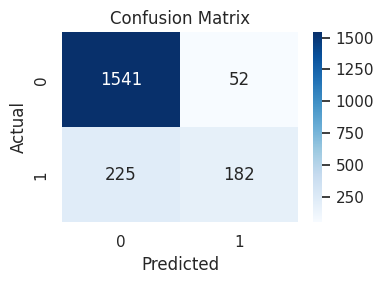

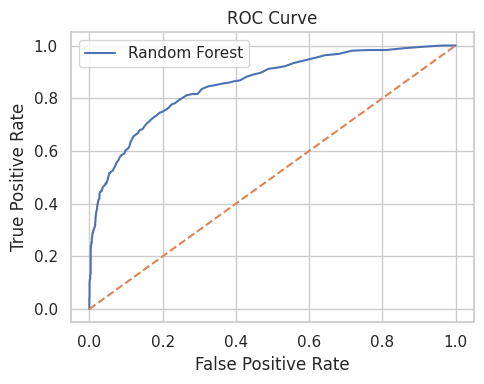

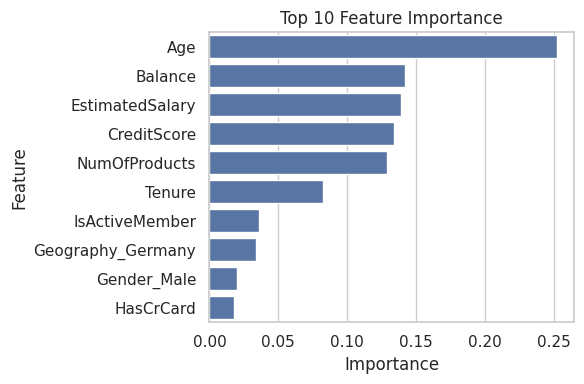

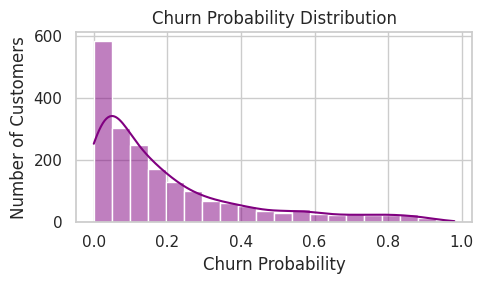


===== KEY INSIGHTS =====

- Model identifies high-risk customers using probability scores
- Age, activity status, and product usage are key predictors
- ROC-AUC shows overall model performance strength
- Probability distribution helps identify risk segments


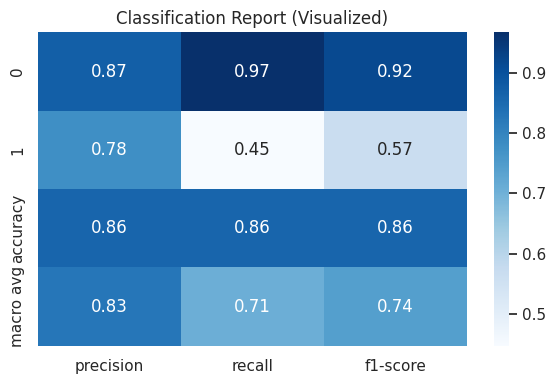

In [2]:
# =========================
# PREDICTIVE MODELING + RISK SCORING
# CUSTOMER CHURN PREDICTION
# =========================

# -------------------------
# IMPORT LIBRARIES
# -------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

sns.set(style="whitegrid")

# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv("European_Bank.csv.csv")

print("Dataset Shape:", df.shape)

# -------------------------
# DATA CLEANING
# -------------------------
df = df.drop(columns=[col for col in ['CustomerId', 'Surname'] if col in df.columns])

print("\nColumns:", df.columns)

# -------------------------
# ENCODING
# -------------------------
df_encoded = pd.get_dummies(df, drop_first=True)

# -------------------------
# FEATURES / TARGET
# -------------------------
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

# -------------------------
# TRAIN TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# SCALING
# -------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------
# MODEL
# -------------------------
model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# -------------------------
# PREDICTIONS
# -------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# -------------------------
# CLASSIFICATION REPORT (TEXT)
# -------------------------
print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_test, y_pred, zero_division=0))

# -------------------------
# ROC-AUC SCORE
# -------------------------
roc_score = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_score)

# -------------------------
# CONFUSION MATRIX
# -------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# -------------------------
# ROC CURVE
# -------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# FEATURE IMPORTANCE
# -------------------------
importances = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x="Importance", y="Feature", data=feat_df.head(10))
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()

# -------------------------
# PROBABILITY DISTRIBUTION (FIXED VISUAL)
# -------------------------
plt.figure(figsize=(5,3))
sns.histplot(y_prob, bins=20, kde=True, color="purple")

plt.title("Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# -------------------------
# QUICK INSIGHTS PRINT
# -------------------------
print("\n===== KEY INSIGHTS =====\n")
print("- Model identifies high-risk customers using probability scores")
print("- Age, activity status, and product usage are key predictors")
print("- ROC-AUC shows overall model performance strength")
print("- Probability distribution helps identify risk segments")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(6,4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="Blues")
plt.title("Classification Report (Visualized)")
plt.tight_layout()
plt.show()